In [33]:
import pypsa


In [34]:
pwd

'/home/ijs/python/pypsa-eur/notebooks'

In [35]:
n = pypsa.Network("../results/iberia-v0-default/networks/base_s_9_elec_Ept80.nc")

# The shape of the model
print(f"Buses: {len(n.buses)}")
print(f"Generators: {len(n.generators)}")  
print(f"Lines: {len(n.lines)}")
print(f"Storage units: {len(n.storage_units)}")
print(f"Snapshots: {len(n.snapshots)}")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, loads, storage_units, sub_networks


Buses: 9
Generators: 57
Lines: 14
Storage units: 21
Snapshots: 8760


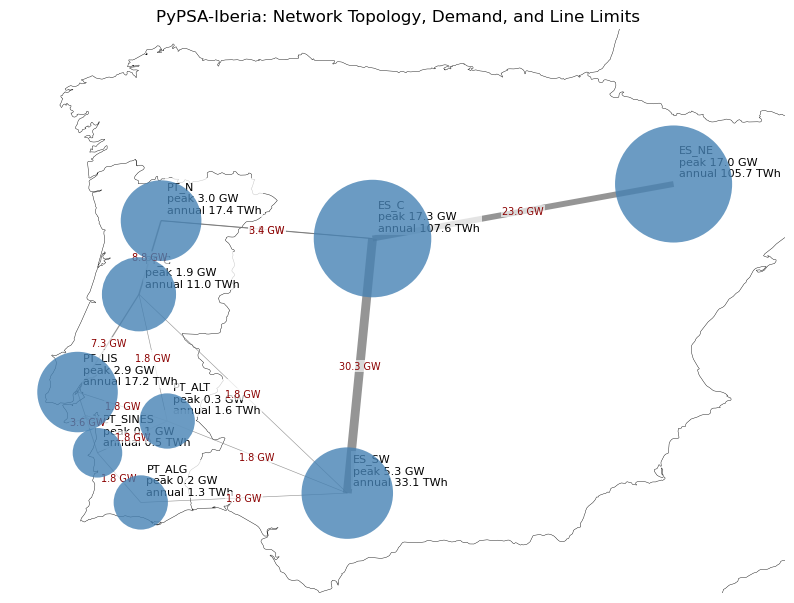

In [36]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

bus_load = n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
mean_load = bus_load.mean()
peak_load_gw = bus_load.max() / 1e3
annual_load_twh = bus_load.sum() / 1e6
bus_size = 0.08 + np.sqrt(mean_load) / 180
line_width = 0.4 + 6 * (n.lines.s_nom / n.lines.s_nom.max()) ** 1.8

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

n.plot.map(
    ax=ax,
    bus_size=bus_size,
    bus_color="steelblue",
    bus_alpha=0.8,
    line_width=line_width,
    line_color="dimgray",
    line_alpha=0.7,
    boundaries=(-10, 1, 36, 44),
    geomap=True,
    geomap_resolution="10m",
)

for bus, row in n.buses.iterrows():
    peak_gw = peak_load_gw.get(bus, 0.0)
    annual_twh = annual_load_twh.get(bus, 0.0)
    ax.text(
        row.x + 0.08,
        row.y + 0.08,
        f"{bus}\npeak {peak_gw:.1f} GW\nannual {annual_twh:.1f} TWh",
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.2),
    )

for line, row in n.lines.iterrows():
    x0, y0 = n.buses.loc[row.bus0, ["x", "y"]]
    x1, y1 = n.buses.loc[row.bus1, ["x", "y"]]
    ax.text(
        (x0 + x1) / 2,
        (y0 + y1) / 2,
        f"{row.s_nom / 1e3:.1f} GW",
        transform=ccrs.PlateCarree(),
        fontsize=7,
        color="darkred",
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=0.8),
    )

ax.set_title("PyPSA-Iberia: Network Topology, Demand, and Line Limits")
plt.show()



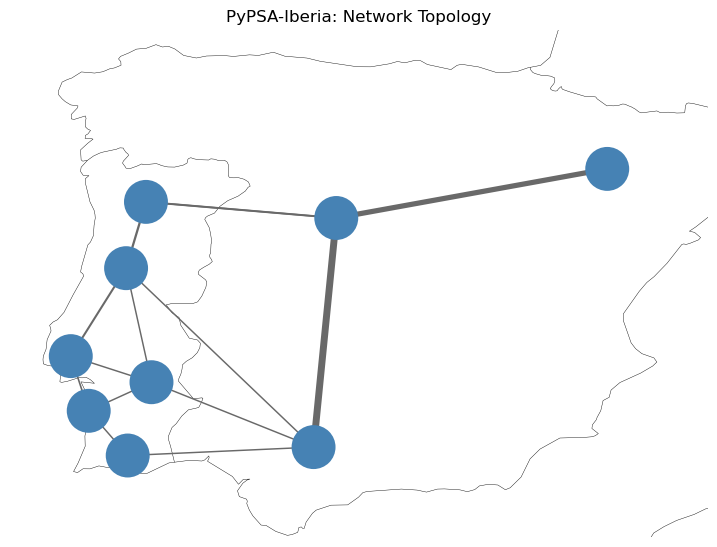

In [37]:
bus_size = 0.12
line_width = 1.0 + 4 * (n.lines.s_nom / n.lines.s_nom.max()) ** 1.5

fig, ax = plt.subplots(
    figsize=(9, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

n.plot.map(
   ax=ax,
   bus_size=bus_size,
   bus_color="steelblue",
   line_width=line_width,
   line_color="dimgray",
   boundaries=(-10, 1, 36, 44),
   geomap=True,
)

ax.set_title("PyPSA-Iberia: Network Topology")
plt.show()

Text(0.5, 1.0, 'Iberian total electricity demand: typical week')

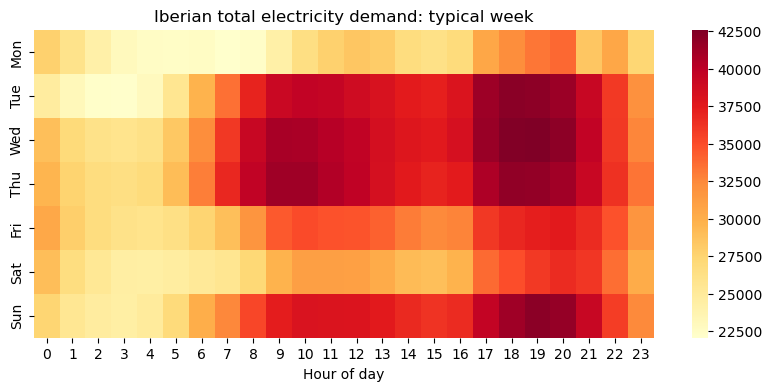

In [38]:
# Demand heatmap (single week)
import pandas as pd
import seaborn as sns

load = n.loads_t.p_set.sum(axis=1)  # total Iberian system load
week = load.iloc[:168].values.reshape(7, 24)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(week, cmap="YlOrRd", ax=ax,
            xticklabels=range(24), yticklabels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_xlabel("Hour of day")
ax.set_title("Iberian total electricity demand: typical week")

Text(0.5, 1.0, 'Optimal generation capacity, Iberian system 2030')

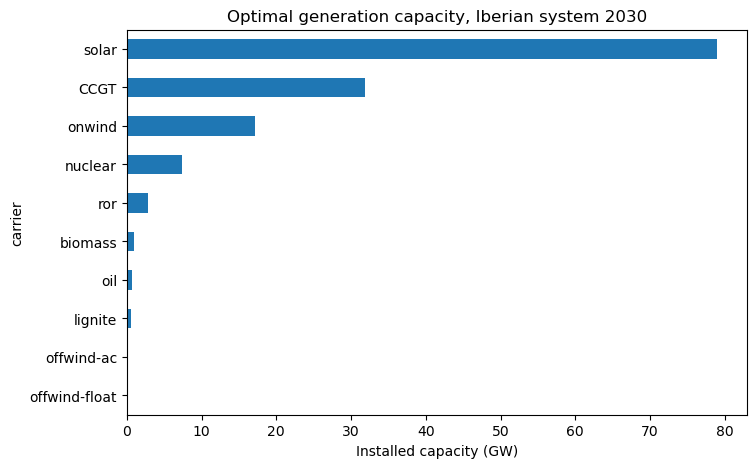

In [39]:
cap = n.generators.groupby('carrier').p_nom_opt.sum() / 1e3  # GW
cap.sort_values().plot.barh(figsize=(8, 5))
plt.xlabel("Installed capacity (GW)")
plt.title("Optimal generation capacity, Iberian system 2030")

Text(0.5, 1.0, 'Optimal capacity by country and technology')

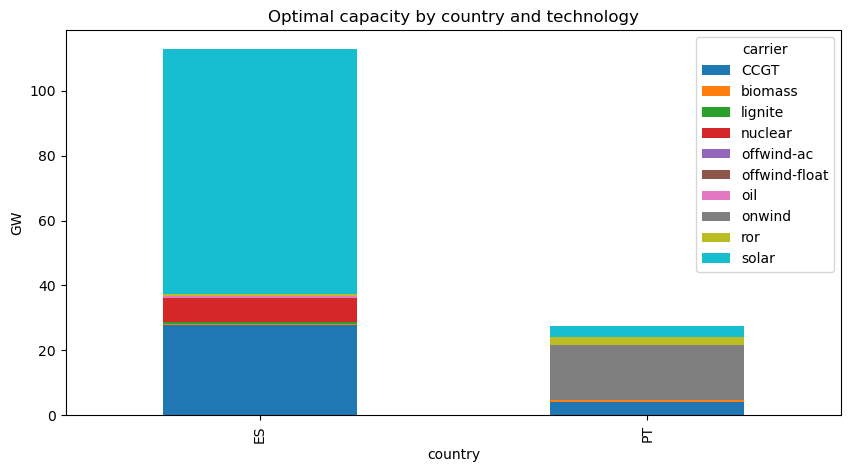

In [40]:
n.generators['country'] = n.generators.bus.map(n.buses.country)
cap_by_country = (n.generators.groupby(['country', 'carrier']).p_nom_opt.sum() / 1e3).unstack()
cap_by_country.plot.bar(stacked=True, figsize=(10, 5))
plt.ylabel("GW")
plt.title("Optimal capacity by country and technology")

Text(0.5, 1.0, 'Solar Capacity by Node: Existing + Added (or Optimized Total)')

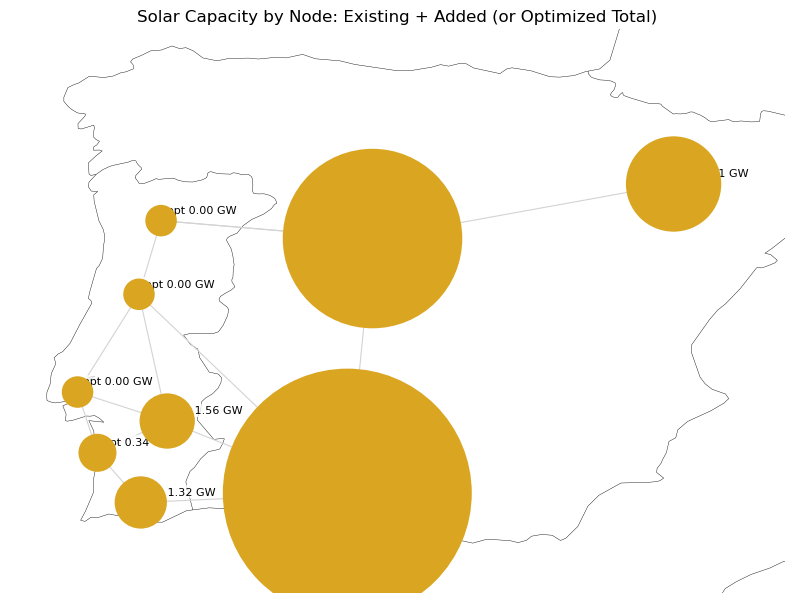

In [41]:
solar = n.generators[n.generators.carrier == "solar"]
solar_existing = solar.groupby("bus")["p_nom"].sum().reindex(n.buses.index, fill_value=0.0)
solar_optimized = solar.groupby("bus")["p_nom_opt"].sum().reindex(n.buses.index, fill_value=0.0)
solar_added = (solar_optimized - solar_existing).clip(lower=0.0)
solar_total_size = 0.05 + solar_optimized / 1.5e4
solar_existing_size = solar_existing / 1.5e4

fig, ax = plt.subplots(figsize=(10, 8),
                       subplot_kw={"projection": ccrs.PlateCarree()})
n.plot.map(
    ax=ax,
    bus_size=solar_total_size,
    bus_color="goldenrod",
    bus_alpha=0.45,
    line_width=0.8,
    line_color="lightgray",
    boundaries=(-10, 1, 36, 44),
)

n.plot.map(
    ax=ax,
    bus_size=solar_existing_size,
    bus_color="darkorange",
    bus_alpha=0.95,
    line_width=0,
    boundaries=(-10, 1, 36, 44),
    geomap=False,
)

for bus, row in n.buses.iterrows():
    existing_gw = solar_existing.get(bus, 0.0) / 1e3
    added_gw = solar_added.get(bus, 0.0) / 1e3
    optimized_gw = solar_optimized.get(bus, 0.0) / 1e3
    if existing_gw > 0:
        label = f"{existing_gw:.2f} + {added_gw:.2f} GW"
    else:
        label = f"opt {optimized_gw:.2f} GW"
    ax.text(
        row.x + 0.08,
        row.y + 0.08,
        label,
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.2),
    )

ax.set_title("Solar Capacity by Node: Existing (inner) and Optimized Total (outer)")

In [42]:
from pathlib import Path

custom_busmap = pd.read_csv("../data/busmaps/base_s_9_osm.csv", dtype=str)
clustered_busmap = pd.read_csv("../resources/busmap_base_s_9.csv", dtype=str)
clustered_network = pypsa.Network("../resources/networks/base_s_9.nc")

custom_busmap = custom_busmap.set_index(custom_busmap.columns[0]).iloc[:, 0].astype(str)
clustered_busmap = clustered_busmap.set_index(clustered_busmap.columns[0]).iloc[:, 0].astype(str)

expected_clusters = sorted(custom_busmap.unique())
clustered_buses = sorted(clustered_network.buses.index.tolist())
solved_buses = sorted(n.buses.index.tolist())

print("Config mode: custom_busmap")
print(f"Custom busmap file: {Path('../data/busmaps/base_s_9_osm.csv').resolve()}")
print(f"Clustered busmap matches custom file: {custom_busmap.sort_index().equals(clustered_busmap.sort_index())}")
print(f"Expected custom clusters ({len(expected_clusters)}): {expected_clusters}")
print(f"Clustered network buses ({len(clustered_buses)}): {clustered_buses}")
print(f"Solved network buses ({len(solved_buses)}): {solved_buses}")

if clustered_buses == expected_clusters:
    print("PASS: resources/networks/base_s_9.nc uses the custom busmap labels.")
else:
    print("FAIL: clustered network does not match the custom busmap labels.")

if solved_buses == expected_clusters:
    print("PASS: solved network still uses the custom busmap labels.")
else:
    print("FAIL: solved network bus labels differ from the custom busmap labels.")
    print("This usually means results/iberia-v0-default is stale and should be rebuilt.")


INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, lines, sub_networks


Config mode: custom_busmap
Custom busmap file: /home/ijs/python/pypsa-eur/data/busmaps/base_s_9_osm.csv
Clustered busmap matches custom file: True
Expected custom clusters (9): ['ES_C', 'ES_NE', 'ES_SW', 'PT_ALG', 'PT_ALT', 'PT_C', 'PT_LIS', 'PT_N', 'PT_SINES']
Clustered network buses (9): ['ES_C', 'ES_NE', 'ES_SW', 'PT_ALG', 'PT_ALT', 'PT_C', 'PT_LIS', 'PT_N', 'PT_SINES']
Solved network buses (9): ['ES_C', 'ES_NE', 'ES_SW', 'PT_ALG', 'PT_ALT', 'PT_C', 'PT_LIS', 'PT_N', 'PT_SINES']
PASS: resources/networks/base_s_9.nc uses the custom busmap labels.
PASS: solved network still uses the custom busmap labels.
